In [24]:
import os, sys
import cv2
import numpy as np
import torch
sys.path.append("../src")
from useful_stuff.general_utils.utils import print_wise
from useful_stuff.image_processing.utils import get_video_dimensions

In [ ]:
def read_video(paths, file_name, folder_name=None, start=0, end=-1, rank=None, to_array=None, conversion=cv2.COLOR_BGR2RGB):
    stimuli_path = f"{paths['data_path']}/stimuli/"
    if not os.path.isdir(stimuli_path): # in the livingstone lab the case is upper
        stimuli_path = f"{paths['data_path']}/Stimuli/"
    # end if not os.path.isdir(stimuli_path):
    if folder_name is not None:
        stimuli_path = f"{stimuli_path}{folder_name}/"
    # end if folder_name is not None:
    fn_path = f"{stimuli_path}{file_name}"
    cap = cv2.VideoCapture(fn_path)
    if not cap.isOpened():
        raise FileNotFoundError(f"Cannot open video file: {fn_path}")
    fps = cap.get(cv2.CAP_PROP_FPS)
    height, width, frames_n = get_video_dimensions(cap)
    video_duration = frames_n*fps # in seconds
    start_frame = int(round(start * fps))
    end_frame   = int(round(end * fps)) if end != -1 else frames_n
    # frame_duration = 1/fps
    # this turns end in frames
    if end_frame > frames_n:
        raise IndexError(f"The selected video {end=} is larger than the video duration={round(video_duration, 3)}")
    # end if end > video_duration:
    if start>0:
        frames_to_skip = round(start*fps) 
        cap.set(cv2.CAP_PROP_POS_FRAMES, frames_to_skip)
    else:
        frames_to_skip = 0
    # end if start>0:
    frames_to_loop = end_frame - frames_to_skip
    video = []
    for _ in range(frames_to_loop):
        ret, frame = cap.read()
        if not ret:
            raise RuntimeError(f"Failed to read frame {round(cap.get(cv2.CAP_PROP_POS_MSEC)*fps/1000)} from {fn_path}")
        
        if conversion is not None:
            frame = cv2.cvtColor(frame, conversion) # can I do something fancier here?
        # end if conversion is not None:
        video.append(frame)
    if to_array is not None:
        if to_array == 'numpy':
            video = np.stack(video)
        elif to_array == 'torch':
            video = [torch.from_numpy(frame).permute(2, 0, 1).float() / 255.0 for frame in video]
            video = torch.stack(video)
        # end if to_array == 'numpy':
    # end if to_array is not None:
    return video
# EOF
        



In [28]:
def read_video(paths, file_name, folder_name=None, start=0, end=-1, rank=None, to_array=None, conversion=cv2.COLOR_BGR2RGB):
    stimuli_path = f"{paths['data_path']}/stimuli/"
    if not os.path.isdir(stimuli_path): # in the livingstone lab the case is upper
        stimuli_path = f"{paths['data_path']}/Stimuli/"
    # end if not os.path.isdir(stimuli_path):
    if folder_name is not None:
        stimuli_path = f"{stimuli_path}{folder_name}/"
    # end if folder_name is not None:
    fn_path = f"{stimuli_path}{file_name}"
    cap = cv2.VideoCapture(fn_path)
    if not cap.isOpened():
        raise FileNotFoundError(f"Cannot open video file: {fn_path}")
    fps = cap.get(cv2.CAP_PROP_FPS)
    height, width, frames_n = get_video_dimensions(cap)
    video_duration_s = frames_n / fps  
    start_frame = int(round(start * fps))
    end_frame   = int(round(end * fps)) if end != -1 else frames_n
    if start_frame >= frames_n:
        raise IndexError(f"{start=} is beyond video length")
    # end if start_frame >= frames_n:
    if end_frame > frames_n:
        raise IndexError(
            f"The selected video {end=} is larger than the video duration={round(video_duration_s, 3)}"
        )
    # end if end_frame > frames_n:
    if end_frame <= start_frame:
        raise ValueError(f"{end=} must be greater than {start=}")

    cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)

    frames_to_loop = int(end_frame - start_frame)

    video = []
    for _ in range(frames_to_loop):
        ret, frame = cap.read()
        if not ret:
            raise RuntimeError(f"Failed to read frame {round(cap.get(cv2.CAP_PROP_POS_MSEC)*fps/1000)} from {fn_path}")
        
        if conversion is not None:
            frame = cv2.cvtColor(frame, conversion) # can I do something fancier here?
        # end if conversion is not None:
        video.append(frame)
    # end for _ in range(frames_to_loop):
    if to_array is not None:
        if to_array == 'numpy':
            video = np.stack(video)
        elif to_array == 'torch':
            video = [torch.from_numpy(frame).permute(2, 0, 1).float() / 255.0 for frame in video]
            video = torch.stack(video)
        # end if to_array == 'numpy':
    # end if to_array is not None:
    cap.release()  
    print_wise(f"finished reading video {fn_path} \nfps={round(fps, 2)}, {height=}, {width=}, n_frames={len(video)}", rank=rank)
    return video
# EOF

In [38]:
paths = {"data_path":"/Users/tizianocausin/1917_local"}
v = read_video(paths, "Project1917_movie_part1_24Hz.mp4", folder_name=None, start=150, end=200, rank=None, to_array=None, conversion=cv2.COLOR_BGR2RGB)


10:21:24 - finished reading video /Users/tizianocausin/1917_local/stimuli/Project1917_movie_part1_24Hz.mp4 
fps=23.98, height=522, width=1280, n_frames=1199


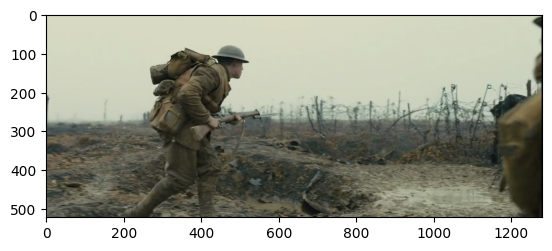

In [39]:
from IPython.display import clear_output
import matplotlib.pyplot as plt
for frame in v:
    plt.imshow(frame)
    plt.show()
    clear_output(wait=True)


# TODO further checks if it works and put it in image processing